<!-- reader-content -->

# Dynamics, pulses, observables, and readout

Start with one pulse and one population trace. Then build a coupled
qubit-resonator model, compare pulse leakage, and simulate its readout response.

## One pulse, one trace

One qubit, one resonator, one Gaussian, and one solve are enough to start.
quchip uses GHz for frequencies and ns for time.

/Users/fermious/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/br/2_469j7j7vg2p9r2p4x4zv240000gn/T/matplotlib-fs4eba6x because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/fermious/.cache/fontconfig
	/Users/fermious/.fontconfig


Matplotlib is building the font cache; this may take a moment.


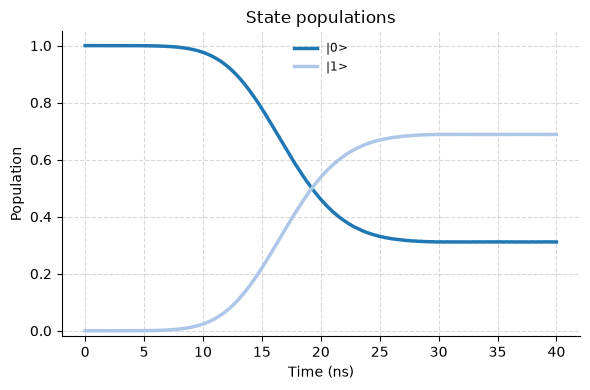

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quchip import (
    RWA,
    Capacitive,
    ChargeDrive,
    Chip,
    DuffingTransmon,
    Gaussian,
    GaussianDRAG,
    QuantumSequence,
    Resonator,
)

q = DuffingTransmon(freq=5.0, anharmonicity=-0.30, levels=3, label="q")
r = Resonator(freq=6.8, levels=4, label="r")
chip = Chip(
    [q, r],
    [Capacitive(q, r, g=0.06, label="qr")],
    frame="rotating",
    approximation=RWA(),
)

line = ChargeDrive(q, label="xy")
chip.wire(line)
sequence = QuantumSequence(chip)
sequence.schedule(
    line,
    envelope=Gaussian(duration=30.0, sigmas=3.0, amplitude=0.025),
    freq=chip.freq(q),
)

result = sequence.simulate(
    tlist=np.linspace(0.0, 40.0, 161),
    initial_state=chip.state({q: 0, r: 0}),
)
result.plot_populations(trace_out=r)
one_pulse_figure = plt.gcf()
one_pulse_figure_path = "../docs/images/dynamics_one_pulse.png"
one_pulse_figure.savefig(one_pulse_figure_path, dpi=180)
plt.show()

```{figure} ../images/dynamics_one_pulse.png
:width: 640px
:alt: Qubit populations during one Gaussian pulse

The population trace comes directly from the stored simulation states.
```

## Build a longer schedule

Pulse amplitude sets the drive strength; duration and `sigmas` set the
bandwidth. The carrier frequency sets detuning, `phase` rotates the drive axis,
and `GaussianDRAG` adds a derivative quadrature through `beta`. Delays advance
a device's control cursors, barriers align cursors, and `vz()` changes the
phase of later microwave pulses without emitting a pulse.

In [2]:
composed = QuantumSequence(chip)
composed.schedule(
    line,
    envelope=GaussianDRAG(
        duration=12.0,
        sigmas=3.0,
        amplitude=0.02,
        beta=-0.4,
    ),
    freq=chip.freq(q) + 0.001,
    phase=0.0,
)
composed.delay(q, duration=5.0)
composed.vz(q, angle=np.pi / 2)
composed.schedule(
    line,
    envelope=Gaussian(duration=12.0, sigmas=3.0, amplitude=0.02),
    freq=chip.freq(q),
)
composed.barrier()

{
    "duration_ns": composed.total_duration,
    "scheduled_pulses": len(composed.scheduled_ops),
    "second_pulse_phase_rad": composed.scheduled_ops[1].phase_offset,
}

{'duration_ns': 29.0,
 'scheduled_pulses': 2,
 'second_pulse_phase_rad': 1.5707963267948966}

<!-- executed-output:start -->

Output:

```text
{'duration_ns': 29.0,
 'scheduled_pulses': 2,
 'second_pulse_phase_rad': 1.5707963267948966}
```

<!-- executed-output:end -->

Use explicit `start_time` only when pulses must overlap. For serial control,
the channel cursors, `delay()`, and `barrier()` make the timing easier to read.

## Add a lossy readout resonator

This example couples a Duffing transmon to a lossy resonator. First we compare
leakage from two qubit pulses. Then we drive the resonator and follow its
response for qubit $|0\rangle$ and $|1\rangle$.

quchip uses GHz for frequencies and ns for time. The chip applies `RWA()` in a
per-device rotating frame to both static interactions and scheduled drives.

In [4]:
import json

import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

from quchip import (
    RWA,
    Capacitive,
    ChargeDrive,
    Chip,
    DuffingTransmon,
    Gaussian,
    GaussianEdge,
    QuantumSequence,
    Resonator,
)

resonator_linewidth = 0.001
truncation_threshold = 1.0e-3

qubit = DuffingTransmon(
    freq=5.0,
    anharmonicity=-0.30,
    levels=6,
    label="q",
)
readout = Resonator(
    freq=6.8,
    levels=10,
    quality_factor=6.8 / resonator_linewidth,
    label="r",
)
chip = Chip(
    [qubit, readout],
    couplings=[
        Capacitive(qubit, readout, g=0.060, label="qr")
    ],
    frame="rotating",
    approximation=RWA(),
)
qubit_line = ChargeDrive(qubit, label="qubit-charge")
readout_line = ChargeDrive(readout, label="readout-charge")
_ = chip.wire(qubit_line, readout_line)

## Inspect the authored Hamiltonian

Before scheduling a pulse, inspect the static Hamiltonian exactly as the
devices and coupling define it. The labels `q`, `r`, and `qr` become compact
operator subscripts; call `.matrix()` only when a numerical array is needed.
`chip.hamiltonian()` is the complementary resolved view after the chip's basis,
frame, and approximation strategy.

In [5]:
chip.unresolved_hamiltonian()

PhysicsExpr(kind='add', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='embed', args=(PhysicsExpr(kind='add', args=(PhysicsExpr(kind='scale', args=(PhysicsExpr(kind='parameter', args=('q.freq', '\\omega', 'GHz'), labels=()), PhysicsExpr(kind='op', args=('n', FockSpace(levels=6)), labels=('q',))), labels=('q',)), PhysicsExpr(kind='scale', args=(PhysicsExpr(kind='mul', args=(PhysicsExpr(kind='literal', args=(0.5,), labels=()), PhysicsExpr(kind='parameter', args=('q.anharmonicity', '\\alpha', 'GHz'), labels=())), labels=()), PhysicsExpr(kind='matmul', args=(PhysicsExpr(kind='op', args=('n', FockSpace(levels=6)), labels=('q',)), PhysicsExpr(kind='sub', args=(PhysicsExpr(kind='op', args=('n', FockSpace(levels=6)), labels=('q',)), PhysicsExpr(kind='op', args=('I', FockSpace(levels=6)), labels=('q',))), labels=('q',))), labels=('q',))), labels=('q',))), labels=('q',)), ('q', 'r'), (6, 10)), labels=('q', 'r')), PhysicsExpr(kind='embed', args=(PhysicsExpr(kind='scale', args=(PhysicsExpr(k

<!-- executed-output:start -->

Output:

```{math}
\omega_{q}\,\hat n_{q} + 0.5\,\alpha_{q}\,\hat n_{q}\,(\hat n_{q} - \hat I_{q}) + \omega_{r}\,\hat n_{r} + g_{qr}\,(\hat a_{q} + \hat a^\dagger_{q})\,(\hat a_{r} + \hat a^\dagger_{r})
```

<!-- executed-output:end -->

## Compare pulse bandwidth and leakage

The coupled chip's dressed transitions set the carrier and the neighboring
line to avoid. Ask quchip for $f_{01}$ and the dressed $1\rightarrow2$
transition:

In [6]:
f01 = float(chip.freq(qubit))
f12 = float(chip.transition_frequency(qubit, 1, 2))

Both pulses are three-sigma Gaussians with the same nominal-$\pi$ area. The
short pulse has bandwidth $|f_{12}-f_{01}|$; the four-times-longer pulse is
more selective. `pi_gaussian` rescales each waveform so
$2\pi\int E(t)\,dt=\pi$.

In [7]:
drive_durations = 3.0 / (np.pi * abs(f12 - f01)) * np.array([1.0, 4.0])


def pi_gaussian(duration: float) -> Gaussian:
    unit_pulse = Gaussian(duration=duration, sigmas=3.0, amplitude=1.0)
    integration_times = np.linspace(0.0, duration, 20001)
    unit_area = integrate.trapezoid(
        np.asarray(unit_pulse.value(integration_times)).real,
        integration_times,
    )
    return Gaussian(
        duration=duration,
        sigmas=3.0,
        amplitude=0.5 / unit_area,
    )


drive_pulses = tuple(pi_gaussian(duration) for duration in drive_durations)
drive_times = np.linspace(0.0, drive_durations[-1], 601)

Both pulses start at $t=0$ from dressed $|0,0\rangle$. The batch varies
duration and amplitude on one shared grid; after the short pulse ends, that
trajectory evolves freely.

In [8]:
drive_sequence = QuantumSequence(chip)
drive = drive_sequence.schedule(qubit_line, envelope=drive_pulses[0], freq=f01)
drive_batch = drive_sequence.simulate_batch(
    drive_sequence.zip(
        drive.vary("duration", drive_durations, name="duration"),
        drive.vary(
            "amplitude",
            [pulse.amplitude for pulse in drive_pulses],
            name="amplitude",
        ),
    ),
    tlist=drive_times,
    initial_state=chip.state({qubit: 0, readout: 0}),
    progress=False,
    truncation_threshold=truncation_threshold,
)

## Inspect populations and truncation

Each batch element is a `SimulationResult`. Read the population and target
overlap, then check that the highest retained levels remain empty.

In [9]:
long_result = drive_batch[1]
target_state = chip.state({qubit: 1, readout: 0})
result_summary = {
    "final_q1_population": float(long_result.population(qubit, 1)[-1]),
    "final_target_overlap": float(long_result.overlap(target_state)[-1]),
    "top_level_populations": long_result.check_truncation(threshold=1.0),
}

result_summary

{'final_q1_population': 0.9798521944788245,
 'final_target_overlap': 0.9805607054904587,
 'top_level_populations': {'q': 8.388689839942628e-17,
  'r': 7.072364146538334e-27}}

<!-- executed-output:start -->

Output:

```text
{'final_q1_population': 0.9798521944788245,
 'final_target_overlap': 0.9805607054904587,
 'top_level_populations': {'q': 8.388689839942628e-17,
  'r': 7.072364146538334e-27}}
```

<!-- executed-output:end -->

Pass `e_ops=chip.e_ops(...)` to `simulate()` when an expectation trace is the
main output. This avoids reconstructing observables from stored states. The
readout calculation below uses that path.

## Plot the pulse comparison

For the shared-grid comparison, read $P_0$, $P_1$, and $P_2$ from the batch.
Each call returns an array indexed by `(pulse, time)`.

In [10]:
drive_populations = np.asarray(
    [drive_batch.population(qubit, level) for level in range(3)]
).real
drive_receipt = {
    "drive_plot": "../docs/images/hello_qubit_drive_leakage.png",
    "durations_ns": dict(zip(("short", "long"), drive_durations, strict=True)),
    "f01_ghz": f01,
    "f12_ghz": f12,
    "final_p1": dict(
        zip(
            ("short", "long"),
            drive_batch.population(qubit, 1, reduce="last"),
            strict=True,
        )
    ),
    "peak_p2": dict(
        zip(
            ("short", "long"),
            drive_batch.population(qubit, 2, reduce="max"),
            strict=True,
        )
    ),
}

The panels show the scheduled envelopes and $P(|0\rangle)$, $P(|1\rangle)$,
and $P(|2\rangle)$. The short pulse reaches the adjacent transition; the long
pulse suppresses that leakage.

RESULT drive={"drive_plot":"../docs/images/hello_qubit_drive_leakage.png","durations_ns":{"long":12.7558825462279,"short":3.188970636556975},"f01_ghz":4.997680964470362,"f12_ghz":4.6982333472347335,"final_p1":{"long":0.9798521944788245,"short":0.3264701196396799},"peak_p2":{"long":0.038702612830927983,"short":0.5637970570725777}}


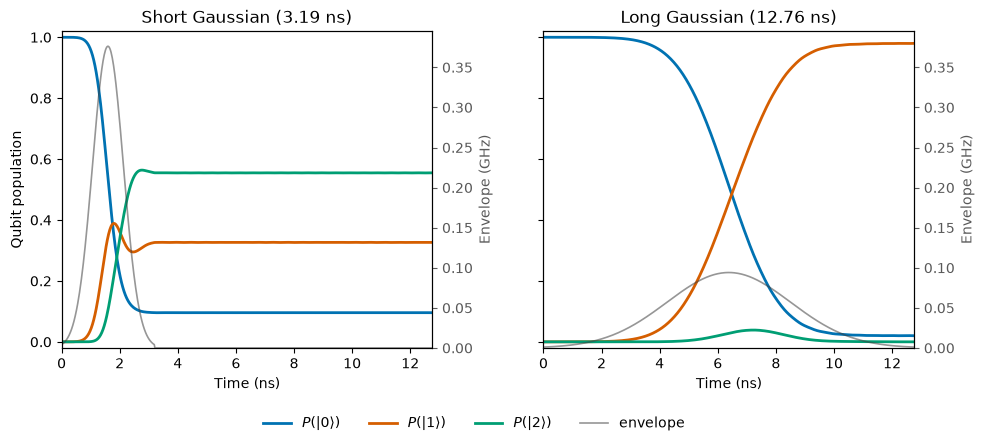

In [11]:
state_colors = ("#0072B2", "#D55E00", "#009E73")
drive_figure, drive_axes = plt.subplots(
    1, 2, figsize=(11.0, 4.8), sharex=True, sharey=True
)
for pulse_index, (axis, name, duration, envelope) in enumerate(
    zip(drive_axes, ("short", "long"), drive_durations, drive_pulses, strict=True)
):
    for level, color in enumerate(state_colors):
        axis.plot(
            drive_times, drive_populations[level, pulse_index],
            color=color, linewidth=2.0, label=fr"$P(|{level}\rangle)$",
        )
    envelope_axis = axis.twinx()
    envelope_axis.plot(
        drive_times,
        np.where(
            drive_times <= duration, envelope.sample(drive_times, real=True), 0.0
        ),
        color="0.25", linewidth=1.2, alpha=0.55, label="envelope",
    )
    envelope_axis.set_ylim(0.0, 1.05 * max(pulse.amplitude for pulse in drive_pulses))
    envelope_axis.set_ylabel("Envelope (GHz)", color="0.35")
    envelope_axis.tick_params(axis="y", colors="0.35")
    axis.set(
        xlim=(0.0, drive_durations[-1]),
        ylim=(-0.02, 1.02),
        xlabel="Time (ns)",
    )
    axis.set_title(f"{name.capitalize()} Gaussian ({duration:.2f} ns)")
    if pulse_index == 0:
        axis.set_ylabel("Qubit population")
        state_handles, state_labels = axis.get_legend_handles_labels()
        envelope_handles, envelope_labels = envelope_axis.get_legend_handles_labels()

drive_figure.legend(
    state_handles + envelope_handles,
    state_labels + envelope_labels,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    ncols=4,
)
drive_figure.subplots_adjust(bottom=0.22, wspace=0.30)

print(f"RESULT drive={json.dumps(drive_receipt, sort_keys=True, separators=(',', ':'))}")
drive_figure.savefig(drive_receipt["drive_plot"], dpi=180)
plt.show()

<!-- executed-output:start -->

Output:

```text
RESULT drive={"drive_plot":"../docs/images/hello_qubit_drive_leakage.png","durations_ns":{"long":12.7558825462279,"short":3.188970636556975},"f01_ghz":4.997680964470362,"f12_ghz":4.6982333472347335,"final_p1":{"long":0.9798521944788245,"short":0.3264701196396799},"peak_p2":{"long":0.038702612830927983,"short":0.5637970570725777}}
```

<!-- executed-output:end -->

```{figure} ../images/hello_qubit_drive_leakage.png
:width: 760px
:alt: Short and long Gaussian pulses with multilevel qubit populations

The short nominal-pi pulse reaches the neighbouring transition. The longer
pulse is more selective.
```

## Simulate dispersive readout

The resonator frequency depends on whether the qubit is in $|0\rangle$ or
$|1\rangle$. Ask quchip for both conditional frequencies:

In [12]:
readout_frequencies = (
    float(chip.freq(readout, when={qubit: 0})),
    float(chip.freq(readout, when={qubit: 1})),
)

The readout lasts for the larger of five resonator lifetimes and half the
inverse conditional pull, rounded up to the 5 ns grid. Its amplitude is set
directly.

In [13]:
readout_time_step = 5.0
readout_duration = readout_time_step * np.ceil(
    max(
        5.0 / (2.0 * np.pi * resonator_linewidth),
        1.0 / (2.0 * abs(readout_frequencies[1] - readout_frequencies[0])),
    )
    / readout_time_step
)
readout_times = np.linspace(
    0.0,
    readout_duration,
    int(round(readout_duration / readout_time_step)) + 1,
)

Schedule that pulse and simulate both prepared states in one quchip batch:

In [14]:
readout_sequence = QuantumSequence(chip)
readout_sequence.schedule(
    readout_line,
    envelope=GaussianEdge(
        duration=readout_duration,
        edge_duration=40.0,
        sigmas=3,
        amplitude=0.0012,
    ),
    freq=sum(readout_frequencies) / 2.0,
)
readout_batch = readout_sequence.simulate_batch(
    readout_sequence.vary(
        "initial_state",
        [
            chip.state({qubit: 0, readout: 0}),
            chip.state({qubit: 1, readout: 0}),
        ],
        name="prepared_qubit",
    ),
    tlist=readout_times,
    e_ops=chip.e_ops(r="a"),
    progress=False,
    truncation_threshold=truncation_threshold,
)

The solver returns $\alpha(t)=\langle a\rangle$; its real and imaginary parts
trace the IQ response for each prepared state.

In [15]:
alpha = np.asarray(readout_batch.expect("r"), dtype=complex)
readout_receipt = {
    "conditional_resonator_frequencies_ghz": readout_frequencies,
    "final_iq_separation": float(abs(alpha[0, -1] - alpha[1, -1])),
    "iq_plot": "../docs/images/hello_dispersive_readout_iq.png",
    "readout_carrier_ghz": sum(readout_frequencies) / 2.0,
    "readout_duration_ns": readout_duration,
    "solver": readout_batch[0].solver,
}

Plot both paths on equal $I/Q$ scales and mark their final points.

RESULT readout={"conditional_resonator_frequencies_ghz":[6.801692857353487,6.801107714624223],"final_iq_separation":0.8107653377042365,"iq_plot":"../docs/images/hello_dispersive_readout_iq.png","readout_carrier_ghz":6.801400285988855,"readout_duration_ns":855.0,"solver":"mesolve"}


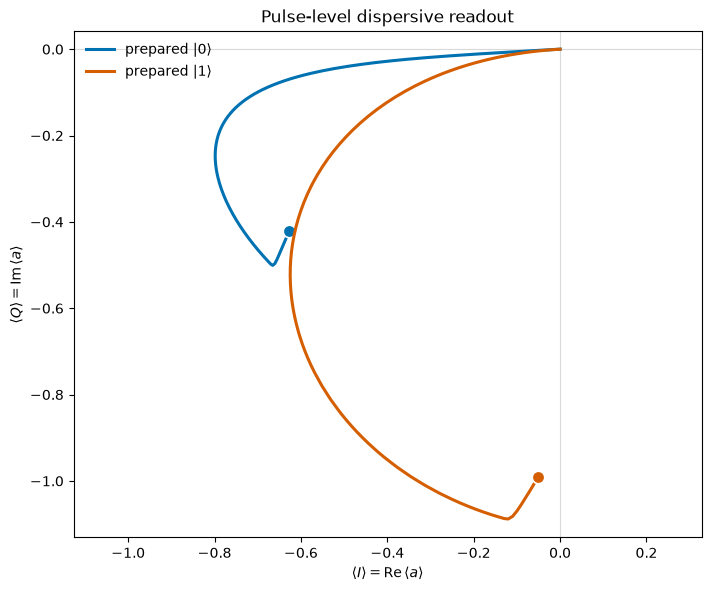

In [16]:
iq_figure, iq_axis = plt.subplots(figsize=(7.0, 5.8), layout="constrained")

for prepared_level, color in enumerate(("#0072B2", "#D55E00")):
    iq_axis.plot(
        alpha[prepared_level].real,
        alpha[prepared_level].imag,
        color=color,
        linewidth=2.2,
        label=fr"prepared $|{prepared_level}\rangle$",
    )
    iq_axis.plot(
        alpha[prepared_level, -1].real,
        alpha[prepared_level, -1].imag,
        marker="o",
        markersize=9,
        markeredgecolor="white",
        markeredgewidth=1.2,
        color=color,
        linestyle="none",
    )

iq_axis.axhline(0.0, color="0.85", linewidth=0.8, zorder=0)
iq_axis.axvline(0.0, color="0.85", linewidth=0.8, zorder=0)
iq_axis.set_xlabel(r"$\langle I\rangle = \mathrm{Re}\,\langle a\rangle$")
iq_axis.set_ylabel(r"$\langle Q\rangle = \mathrm{Im}\,\langle a\rangle$")
iq_axis.set_title("Pulse-level dispersive readout")
iq_axis.set_aspect("equal", adjustable="datalim")
iq_axis.legend(frameon=False, loc="upper left")

print(f"RESULT readout={json.dumps(readout_receipt, sort_keys=True, separators=(',', ':'))}")
iq_figure.savefig(readout_receipt["iq_plot"], dpi=180)
plt.show()

<!-- executed-output:start -->

Output:

```text
RESULT readout={"conditional_resonator_frequencies_ghz":[6.801692857353487,6.801107714624223],"final_iq_separation":0.8107653377042365,"iq_plot":"../docs/images/hello_dispersive_readout_iq.png","readout_carrier_ghz":6.801400285988855,"readout_duration_ns":855.0,"solver":"mesolve"}
```

<!-- executed-output:end -->

```{figure} ../images/hello_dispersive_readout_iq.png
:width: 560px
:alt: Conditional resonator IQ paths with emphasized final points

The prepared qubit states produce different resonator trajectories under the
same readout pulse.
```

## Boundaries of the readout model

`chip.freq(readout, when={qubit: ...})` is a static dressed-spectrum question.
The IQ paths above are time-domain resonator expectation values under a
declared pulse, resonator linewidth, and prepared qubit state. They include
the chip Hamiltonian and its local Lindblad channels.

They do not include an amplifier chain, digitizer, sampled measurement noise,
or a classifier. Those belong in a measurement model built from the simulated
output. Likewise, `T1`, `T2`, `thermal_population`, and resonator
`quality_factor` describe device-level relaxation, dephasing, heating, and
photon loss; they are not a complete laboratory noise budget.

## Dynamics map

Use `simulate()` for one experiment and `simulate_batch()` for parameter or
initial-state studies. Batch axes are independent by default; `sequence.zip()`
pairs values such as pulse duration and its calibrated amplitude. Read
populations for occupations, expectations for observables, overlaps for target
states, and reduced states when you need one subsystem. Check truncation before
trusting a small local basis.